<a href="https://colab.research.google.com/github/polokocodes/Poloko-Assignment-2/blob/main/Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Project 2: Exploratory Data Analysis
#Topic: Which location has the highest salary comp
Questions:
1. How does salaries differ across job types, location, categories and experiance levels.
2. The relationship between experiance and job type.
3. What skills are most in demand.

#STEP 1:Data Selection

In [35]:
from google.colab import files
import pandas as pd
import numpy as np
job_data = pd.read_csv("/content/job_market.csv")




In [36]:
job_data.tail()

,job_title,company,location,job_type,category,salary_min,salary_max,experience_required,publication_date,skills
245,Data Analyst,InnovateLab,"Austin, TX",Part-time,Technology,51888,91798,3.0,2025-11-27,"Python, TypeScript, TensorFlow, Ruby"
246,Business Analyst,DigitalWorks,"Toronto, Canada",Part-time,Technology,52419,90437,2.0,2025-11-27,"Python, CI/CD, Machine Learning, SQL"
247,(Junior) Testautomatisierer (m/w/d) #LowCode,Greenfield Technology AG,Düsseldorf,NaN,Remote,45000,70000,NaN,1764203502,NaN
248,(Junior) Media Buyer Influencer Marketing (m/w/d),benuta GmbH,Cologne,Contract,Marketing and Communication,45000,70000,NaN,1764178292,NaN
249,(Junior) Softwareentwickler (m/w/d) #LowCode,Greenfield Technology AG,Düsseldorf,NaN,Remote,45000,70000,NaN,1764203503,NaN


In [37]:
#Data description
print("Data description: \n",job_data.describe())
#Data shape
print("Data columns(10) and rows(250): \n",job_data.shape)
#Name of features and targets
print("\n Columns: \n",job_data.columns.tolist())
#Number of missing data
print("\n Missing data: \n", job_data.isnull().sum())
#Data type check
print("\n Data types: \n", job_data.dtypes)
#Variable distribution
print("\n Variable distribution: \n", job_data.nunique())


Data description: 
           salary_min     salary_max  experience_required
count     250.000000     250.000000           207.000000
mean    89067.900000  155685.424000             4.227053
std     23183.593666   42842.170809             2.461676
min     45000.000000   70000.000000             0.000000
25%     71880.500000  130631.750000             2.500000
50%     88136.000000  149535.000000             4.000000
75%    105755.250000  186913.500000             5.000000
max    156891.000000  291345.000000            12.000000
Data columns(10) and rows(250): 
 (250, 10)

 Columns: 
 ['job_title', 'company', 'location', 'job_type', 'category', 'salary_min', 'salary_max', 'experience_required', 'publication_date', 'skills']

 Missing data: 
 job_title               0
company                 0
location                0
job_type               29
category               20
salary_min              0
salary_max              0
experience_required    43
publication_date        0
skills          

/tmp/ipykernel_385/3074570773.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=job_null_counts.values,y=job_null_counts.index,palette='viridis')


Text(0, 0.5, 'Columns')

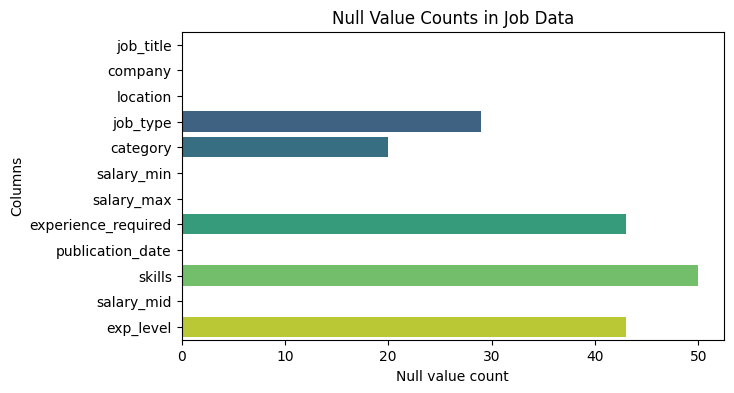

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

job_null_counts = job_data.isnull().sum()
plt.figure(figsize=(7, 4))
sns.barplot(x=job_null_counts.values,y=job_null_counts.index,palette='viridis')
plt.title('Null Value Counts in Job Data')
plt.xlabel('Null value count')
plt.ylabel('Columns')

In [38]:
job_data['location'].value_counts()

,count
location,
"Austin, TX",27
"Boston, MA",23
"New York, NY",20
"Denver, CO",20
"Atlanta, GA",17
"Chicago, IL",16
"Toronto, Canada",16
Remote,16
"San Francisco, CA",14


In [39]:
job_data['job_title'].value_counts()


,count
job_title,
Machine Learning Engineer,14
Solutions Architect,13
Software Engineer,13
Technical Lead,13
Senior Software Engineer,12
Scooter Mechanic,11
Project Manager,10
Business Analyst,10
Frontend Developer,9


In [40]:
job_data['category'].value_counts()

,count
category,
Technology,200
Remote,11
Marketing and Communication,6
Software Development,4
Social Media Manager,2
Recruitment and Selection,1
SAP/ERP Consulting,1
Helpdesk,1
Media Planning,1


#Step 2: Exploratory Data Analysis

/tmp/ipykernel_385/2391974547.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=filtered_data,


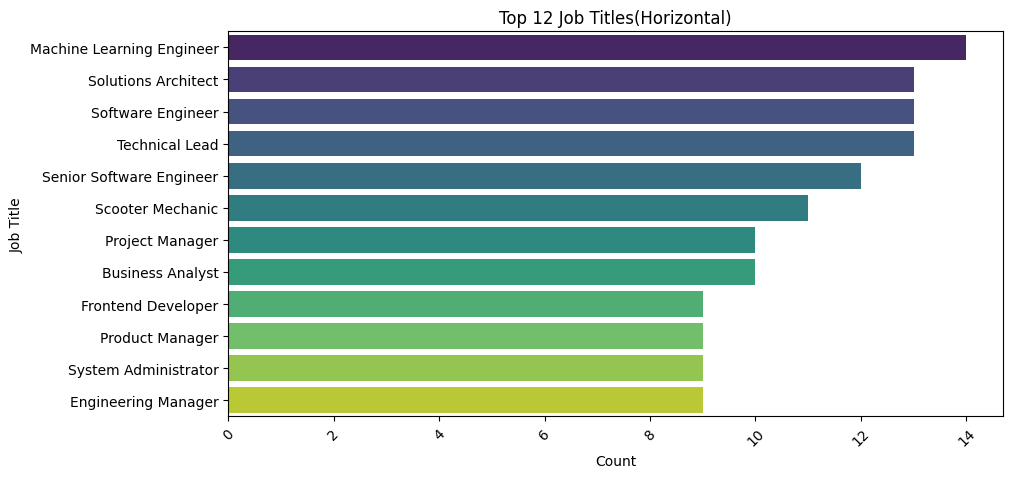

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

#What is the most popular job
# 1. Identify the top 12 job titles
top_12_titles = job_data['job_title'].value_counts().head(12).index

# 2. Filter the dataframe to only include those titles
filtered_data = job_data[job_data['job_title'].isin(top_12_titles)]

# 3. Plot the filtered data
plt.figure(figsize=(10, 5))
sns.countplot(data=filtered_data,
              y='job_title',
              order=top_12_titles,
              palette='viridis')

plt.xticks(rotation=45) # Rotates labels so they don't overlap
plt.xlabel('Count')
plt.ylabel('Job Title')
plt.title('Top 12 Job Titles(Horizontal)')
plt.show()

**How salary differs across different varibles**

/tmp/ipykernel_385/1953618333.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=filtered_data,


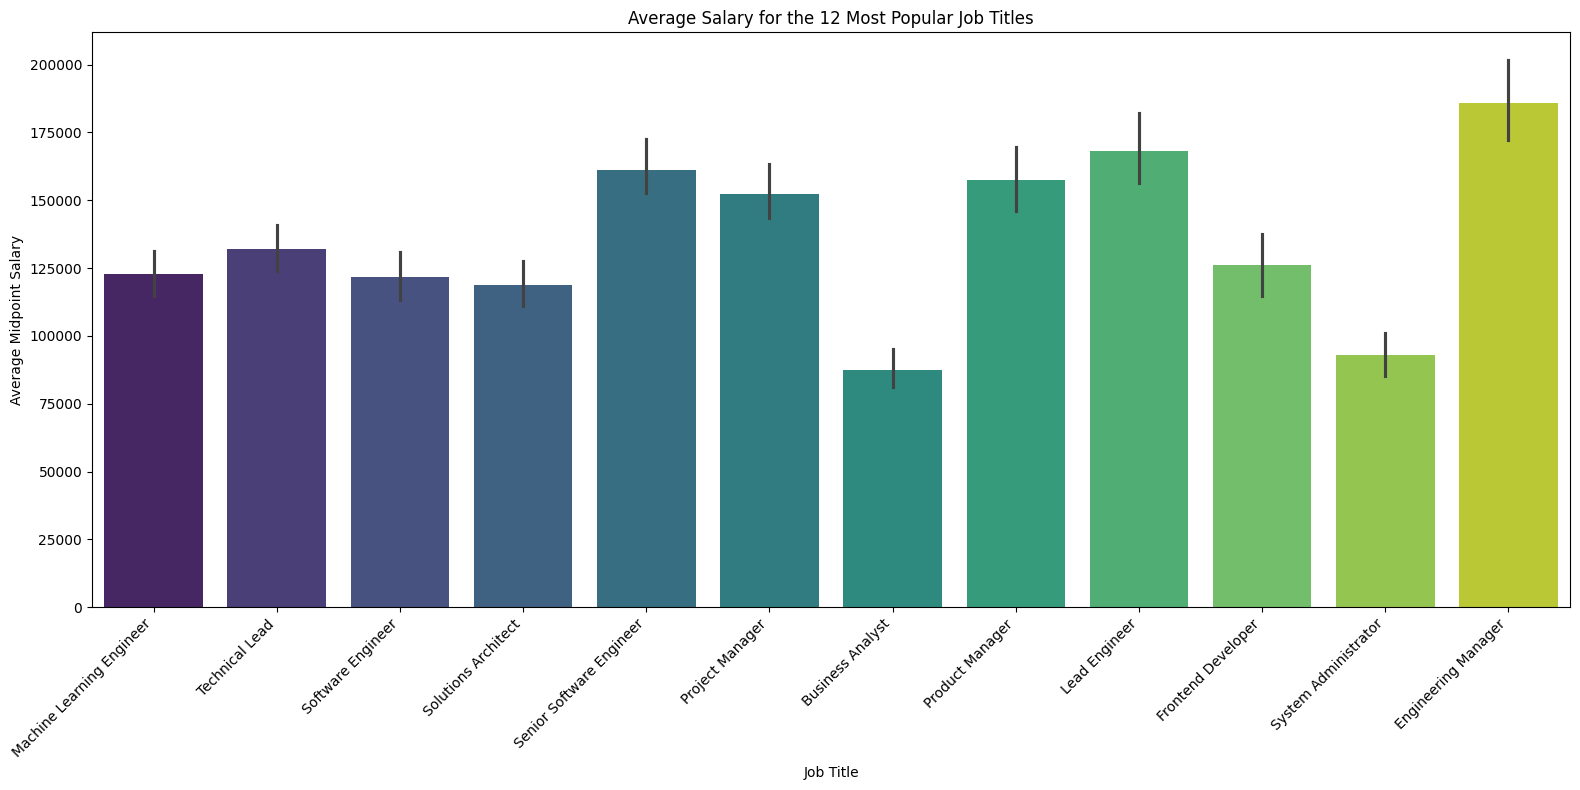

In [63]:
# Q4 — How does salary differ across job types, locations, categories, and experience levels?


#Salary relative too job title

to_drop = job_data[job_data['job_title'] == 'Scooter Mechanic'].index
job_data = job_data.drop(to_drop)

# 1. Salary midpoint calculation
job_data['salary_mid'] = (job_data['salary_min'] + job_data['salary_max']) / 2

# 2. Identify the top 12 most frequent job titles
top_12_titles = job_data['job_title'].value_counts().head(12).index

# 3. Filter the dataframe
filtered_data = job_data[job_data['job_title'].isin(top_12_titles)]

# 4. Plot Salary vs Job Title
plt.figure(figsize=(16, 8))
sns.barplot(data=filtered_data,
            x='job_title',
            y='salary_mid',
            order=top_12_titles,
            palette='viridis'
            )

plt.xticks(rotation=45, ha='right')
plt.xlabel('Job Title')
plt.ylabel('Average Midpoint Salary')
plt.title('Average Salary for the 12 Most Popular Job Titles')
plt.tight_layout()
plt.show()





/tmp/ipykernel_385/2398348156.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=loc_filtered_data,


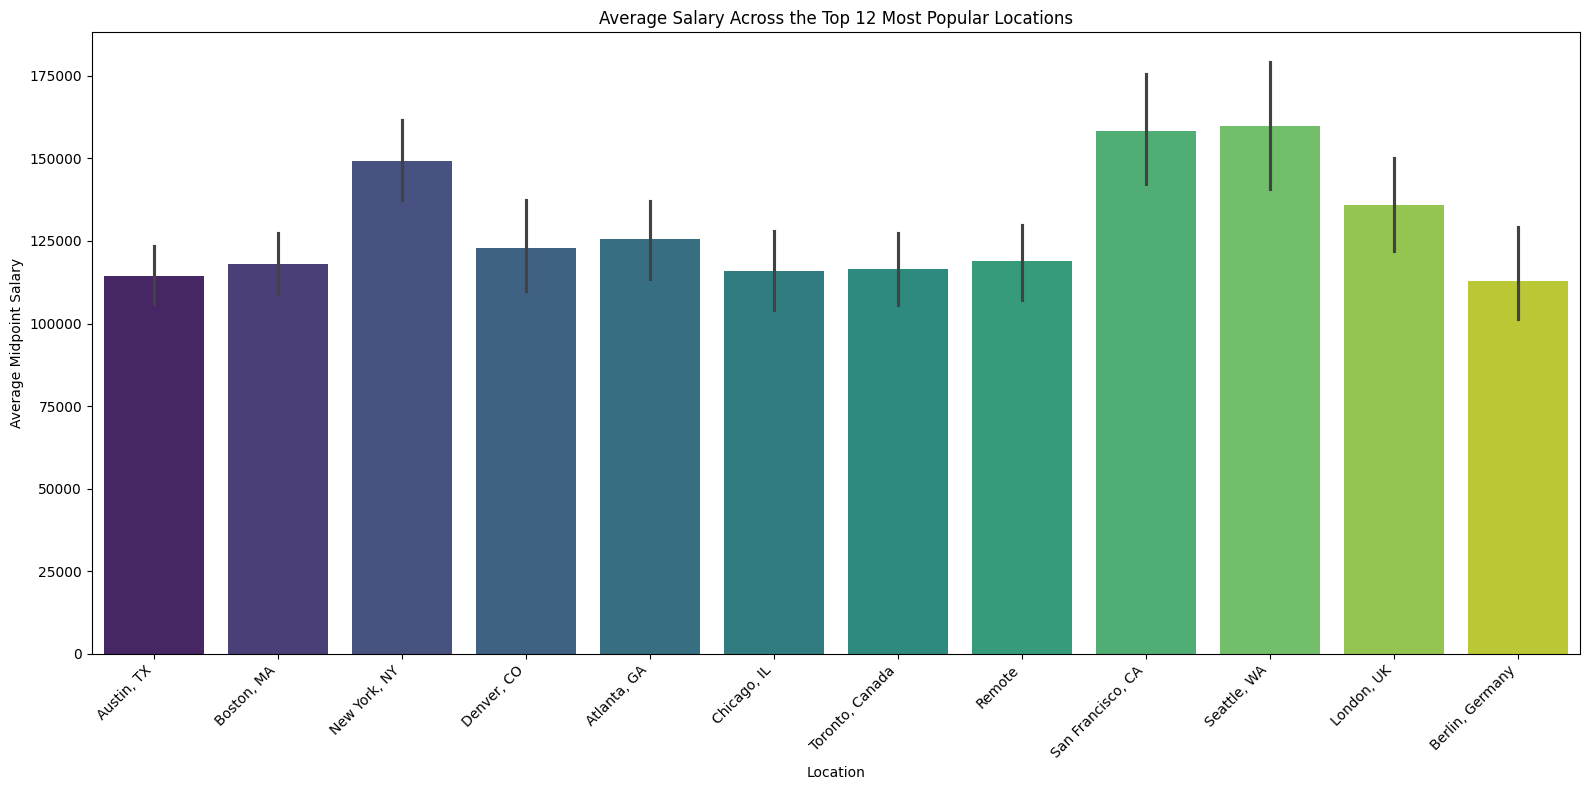

In [43]:
#How salary relates to location

# 1. Identify the top 12 locations with the most job postings
top_12_locations = job_data['location'].value_counts().head(12).index

# 2. Filter the dataframe for these locations
loc_filtered_data = job_data[job_data['location'].isin(top_12_locations)]

# 3. Plot Salary vs Location
plt.figure(figsize=(16, 8))

# We use 'location' as x and 'salary_mid' as y
sns.barplot(data=loc_filtered_data,
            x='location',
            y='salary_mid',
            order=top_12_locations,
            palette='viridis'
            )

plt.xticks(rotation=45, ha='right')
plt.xlabel('Location')
plt.ylabel('Average Midpoint Salary')
plt.title('Average Salary Across the Top 12 Most Popular Locations')
plt.tight_layout()
plt.show()

/tmp/ipykernel_385/3896420695.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=filtered_data,


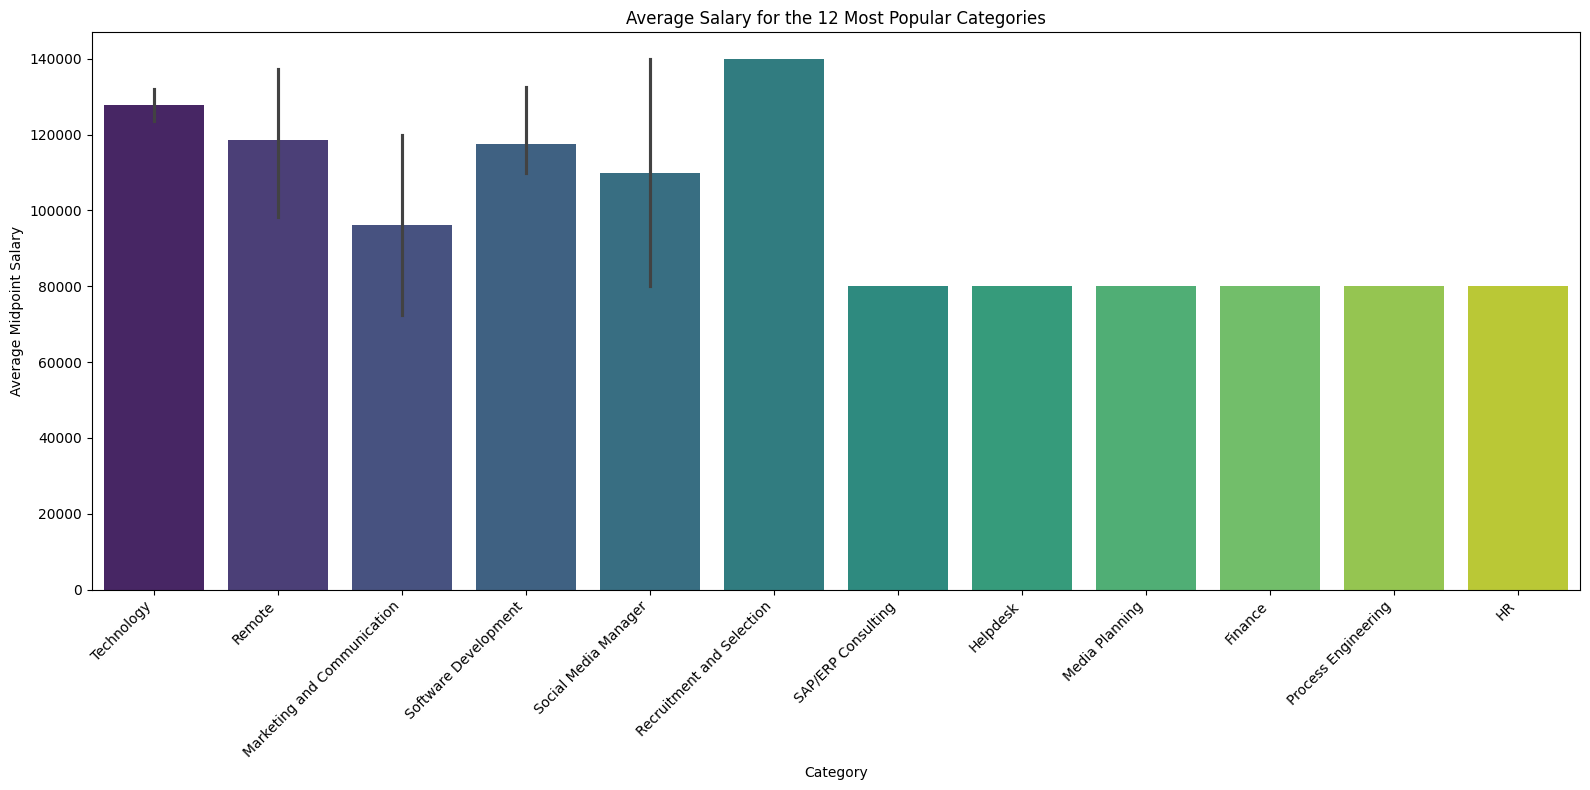

In [44]:
#How salary relates to job category


# 2. Identify the top 12 most frequent categories
top_12_categories = job_data['category'].value_counts().head(12).index

# 3. Filter the dataframe
filtered_data = job_data[job_data['category'].isin(top_12_categories)]

# 4. Plot Salary vs Category
plt.figure(figsize=(16, 8))
sns.barplot(data=filtered_data,
            x='category',
            y='salary_mid',
            order=top_12_categories,
            palette='viridis'
            )

plt.xticks(rotation=45, ha='right')
plt.xlabel('Category')
plt.ylabel('Average Midpoint Salary')
plt.title('Average Salary for the 12 Most Popular Categories')
plt.tight_layout()
plt.show()

/tmp/ipykernel_385/3281148600.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=labels, palette='magma')


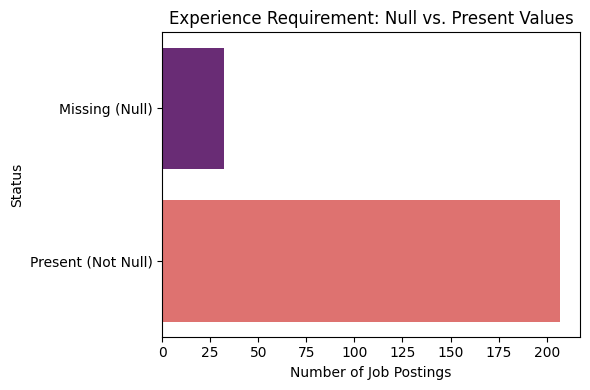

In [73]:
# 1. Calculate counts
null_exp = job_data['experience_required'].isnull().sum()
exp_not_null = job_data['experience_required'].notnull().sum()

# 2. Create the data structure for plotting
counts = [null_exp, exp_not_null]
labels = ['Missing (Null)', 'Present (Not Null)']

# 3. Plotting
plt.figure(figsize=(6, 4))
# Pass labels to y and counts to x for a horizontal bar
sns.barplot(x=counts, y=labels, palette='magma')

plt.xlabel('Number of Job Postings')
plt.ylabel('Status')
plt.title('Experience Requirement: Null vs. Present Values')
plt.tight_layout()
plt.show()

/tmp/ipykernel_385/1379849465.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=job_data,


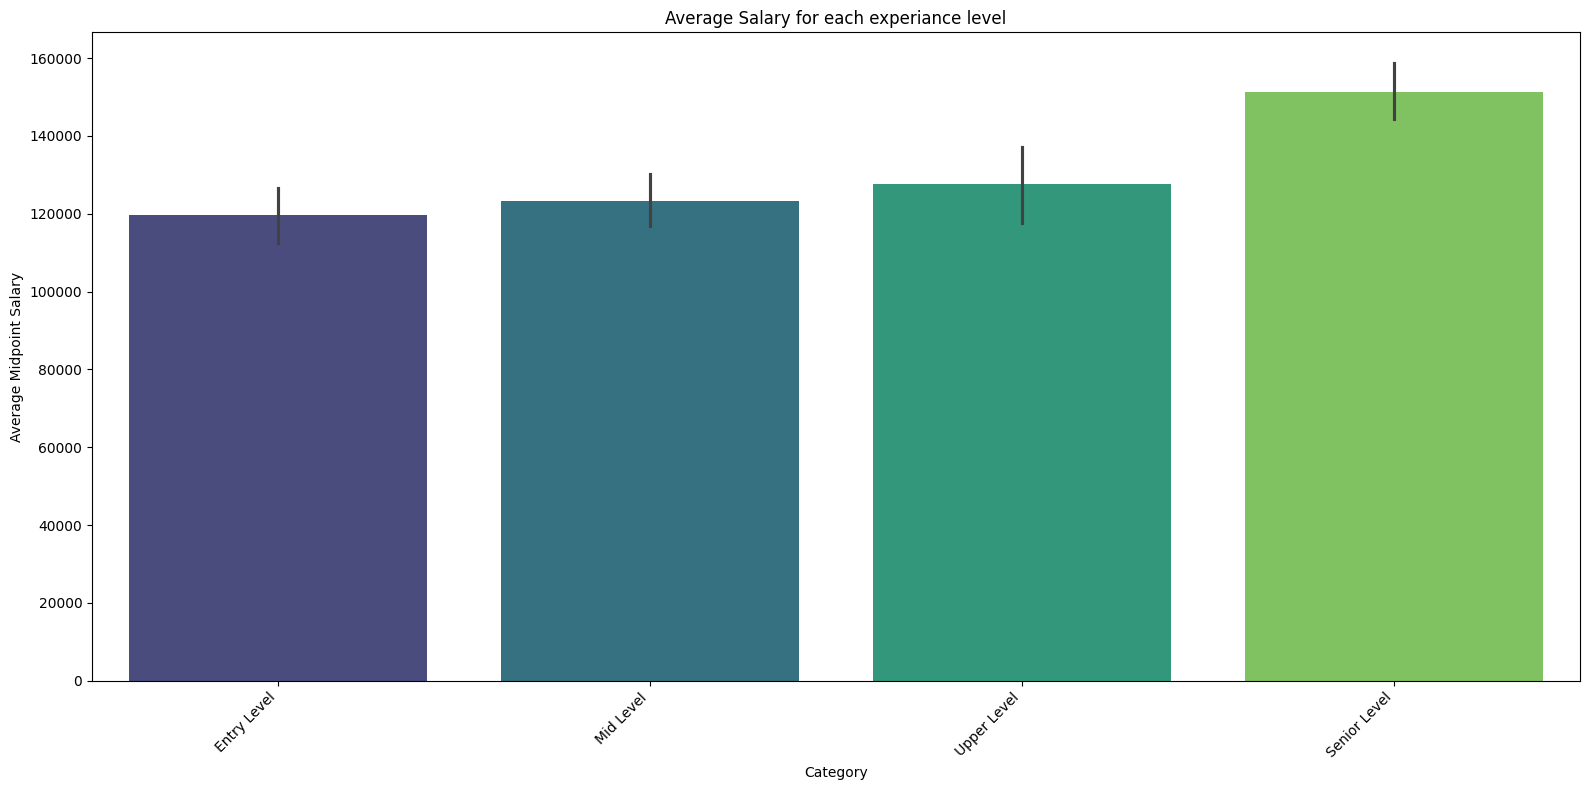

In [45]:
#Create experiance level labels
exp_labels = ['Entry Level', 'Mid Level','Upper Level', 'Senior Level']

#New experiance level column
job_data['exp_level'] = pd.qcut(job_data['experience_required'],q=4,labels=exp_labels)


# 2. Identify the top 12 most frequent categories
#top_12_ = job_data['category'].value_counts().head(12).index

# 3. Filter the dataframe
#filtered_data = job_data[job_data['category'].isin(top_12_categories)]

# 4. Plot Salary vs Category
plt.figure(figsize=(16, 8))
sns.barplot(data=job_data,
            x='exp_level',
            y='salary_mid',
            order=exp_labels,
            palette='viridis'
            )

plt.xticks(rotation=45, ha='right')
plt.xlabel('Category')
plt.ylabel('Average Midpoint Salary')
plt.title('Average Salary for each experiance level')
plt.tight_layout()
plt.show()

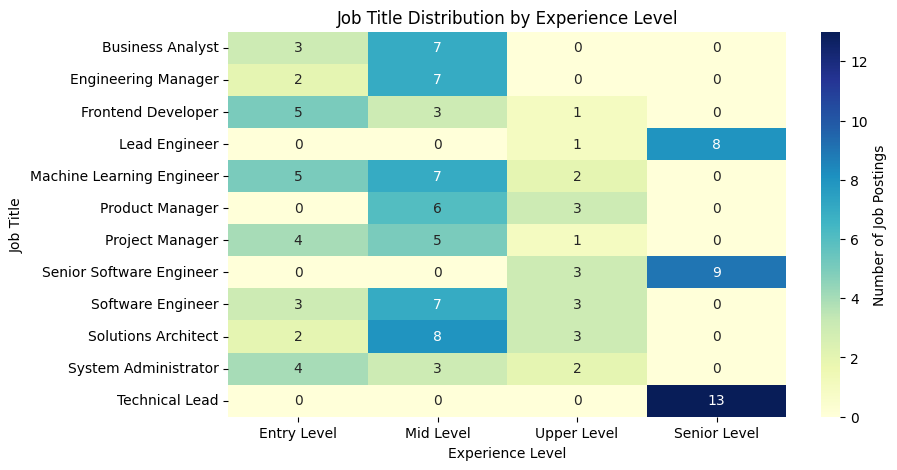

In [67]:
# 1. Prepare the data: Create a cross-tabulation of Job Title vs Experience Level
# We use only the top 12 titles we identified earlier
exp_matrix = pd.crosstab(filtered_data['job_title'], job_data['exp_level'])

# 2. Reorder the columns to follow logical career progression
exp_matrix = exp_matrix[['Entry Level', 'Mid Level', 'Upper Level', 'Senior Level']]

# 3. Plotting
plt.figure(figsize=(9, 5))
sns.heatmap(exp_matrix,
            annot=True,    # Shows the actual counts in the squares
            fmt='d',       # Formats numbers as integers
            cmap='YlGnBu', # A nice color gradient from Yellow to Blue
            cbar_kws={'label': 'Number of Job Postings'})

plt.title('Job Title Distribution by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Job Title')
plt.show()

/tmp/ipykernel_385/1643696820.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=skill_counts.values, y=skill_counts.index, palette='magma')


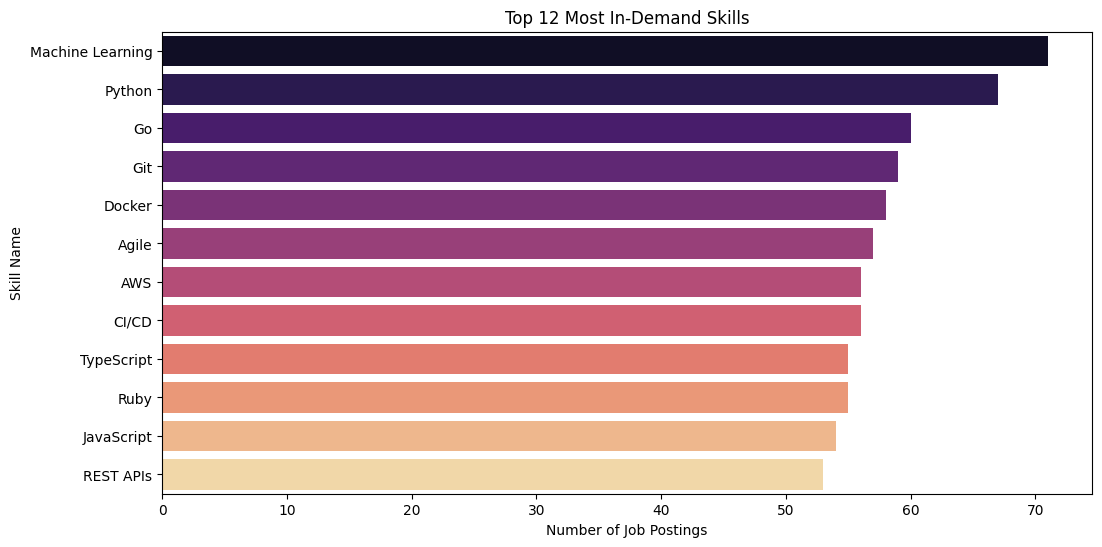

In [47]:
#What is the most in demand skill
skill_counts = job_data['skills'].str.split(',').explode().str.strip().value_counts().head(12)

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x=skill_counts.values, y=skill_counts.index, palette='magma')

plt.title('Top 12 Most In-Demand Skills')
plt.xlabel('Number of Job Postings')
plt.ylabel('Skill Name')
plt.show()

/tmp/ipykernel_385/1745654711.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=labels, palette='magma')


Text(0, 0.5, 'Status')

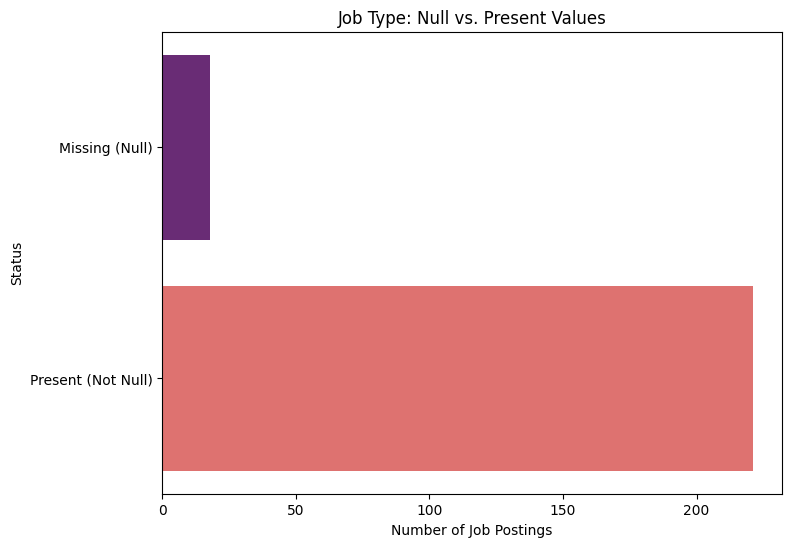

In [74]:
#How does job type affect salary
null_type = job_data['job_type'].isnull().sum()
type_not_null = job_data['job_type'].notnull().sum()

counts= [null_type, type_not_null]
labels = ['Missing (Null)', 'Present (Not Null)']

plt.figure(figsize=(8,6))
sns.barplot(x=counts, y=labels, palette='magma')
plt.title('Job Type: Null vs. Present Values')
plt.xlabel('Number of Job Postings')
plt.ylabel('Status')

/tmp/ipykernel_385/1975633671.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=job_data_clean,


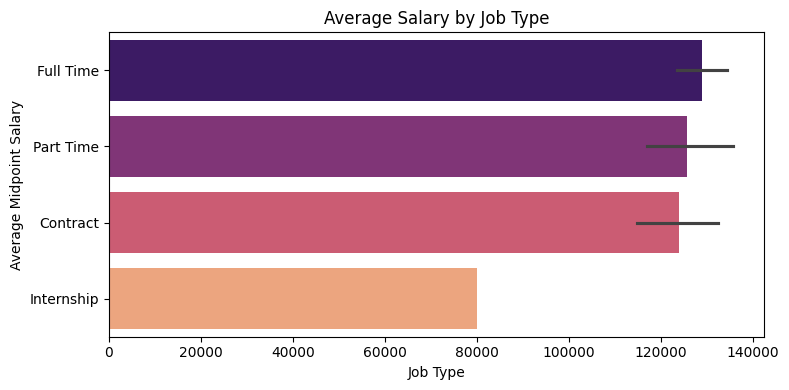

In [84]:
# Standardize job_type values
job_type_mapping = {
    'Full Time': 'Full Time',
    'Full-Time': 'Full Time',
    'Full-time': 'Full Time',
    'Part Time': 'Part Time',
    'Part-Time': 'Part Time',
    'Part-time': 'Part Time',
    'Contract': 'Contract',
    'Internship': 'Internship',
    'Remote': 'Full Time',          # Remote is a work arrangement, not a job type
    'Manager': 'Full Time',         # Likely mislabeled
    'Berufserfahren': 'Full Time',   # German: "Experienced professional"
    'Berufseinstieg': 'Entry Level', # German: "Entry level"
    'Professional / Experienced': 'Full Time',
    'Working Student': 'Part Time',  # German: "Werkstudent"
}

job_data['job_type'] = job_data['job_type'].str.strip().map(job_type_mapping)
job_data_clean = job_data.dropna(subset=['job_type'])

plt.figure(figsize=(8, 4))
sns.barplot(data=job_data_clean,
            y='job_type',
            x='salary_mid',
            order=job_data_clean.groupby('job_type')['salary_mid'].mean().sort_values(ascending=False).index,
            palette='magma')

plt.xlabel('Job Type')
plt.ylabel('Average Midpoint Salary')
plt.title('Average Salary by Job Type')
plt.tight_layout()
plt.show()